In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats


In [2]:
data = pd.read_csv("global_cancer_patients_2015_2024.csv")


In [5]:
data.head(10)

,Patient_ID,Age,Gender,Country_Region,Year,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Cancer_Type,Cancer_Stage,Treatment_Cost_USD,Survival_Years,Target_Severity_Score
0,PT0000000,71,Male,UK,2021,6.4,2.8,9.5,0.9,8.7,Lung,Stage III,62913.44,5.9,4.92
1,PT0000001,34,Male,China,2021,1.3,4.5,3.7,3.9,6.3,Leukemia,Stage 0,12573.41,4.7,4.65
2,PT0000002,80,Male,Pakistan,2023,7.4,7.9,2.4,4.7,0.1,Breast,Stage II,6984.33,7.1,5.84
3,PT0000003,40,Male,UK,2015,1.7,2.9,4.8,3.5,2.7,Colon,Stage I,67446.25,1.6,3.12
4,PT0000004,43,Female,Brazil,2017,5.1,2.8,2.3,6.7,0.5,Skin,Stage III,77977.12,2.9,3.62
5,PT0000005,22,Male,Germany,2018,9.5,6.4,3.3,3.9,5.1,Cervical,Stage IV,33468.99,9.5,5.98
6,PT0000006,41,Male,Canada,2021,5.1,8.2,0.3,3.7,2.1,Cervical,Stage 0,9790.83,1.0,5.05
7,PT0000007,72,Female,Canada,2018,6.0,8.2,6.4,0.6,8.5,Prostate,Stage I,17161.40,6.2,6.02
8,PT0000008,21,Male,USA,2022,4.3,3.8,1.0,0.3,8.5,Lung,Stage II,56458.48,6.5,3.36
9,PT0000009,49,Female,Canada,2016,8.1,0.8,7.8,5.2,9.3,Prostate,Stage II,56133.45,5.7,5.76


Understand the Dataset

In [7]:
data.shape

(50000, 15)

In [10]:
data.columns

Index(['Patient_ID', 'Age', 'Gender', 'Country_Region', 'Year', 'Genetic_Risk',
       'Air_Pollution', 'Alcohol_Use', 'Smoking', 'Obesity_Level',
       'Cancer_Type', 'Cancer_Stage', 'Treatment_Cost_USD', 'Survival_Years',
       'Target_Severity_Score'],
      dtype='object')

In [8]:
data.info

<bound method DataFrame.info of       Patient_ID  Age  Gender Country_Region  Year  Genetic_Risk  \
0      PT0000000   71    Male             UK  2021           6.4   
1      PT0000001   34    Male          China  2021           1.3   
2      PT0000002   80    Male       Pakistan  2023           7.4   
3      PT0000003   40    Male             UK  2015           1.7   
4      PT0000004   43  Female         Brazil  2017           5.1   
...          ...  ...     ...            ...   ...           ...   
49995  PT0049995   80    Male       Pakistan  2023           2.3   
49996  PT0049996   40  Female            USA  2018           6.4   
49997  PT0049997   74    Male       Pakistan  2015           6.2   
49998  PT0049998   21    Male         Brazil  2018           4.0   
49999  PT0049999   22    Male       Pakistan  2023           5.1   

       Air_Pollution  Alcohol_Use  Smoking  Obesity_Level Cancer_Type  \
0                2.8          9.5      0.9            8.7        Lung   
1    

In [11]:
data.describe()

,Age,Year,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Treatment_Cost_USD,Survival_Years,Target_Severity_Score
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,54.421540,2019.480520,5.001698,5.010126,5.010880,4.989826,4.991176,52467.298239,5.006462,4.951207
std,20.224451,2.871485,2.885773,2.888399,2.888769,2.881579,2.894504,27363.229379,2.883335,1.199677
min,20.000000,2015.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5000.050000,0.000000,0.900000
25%,37.000000,2017.000000,2.500000,2.500000,2.500000,2.500000,2.500000,28686.225000,2.500000,4.120000
50%,54.000000,2019.000000,5.000000,5.000000,5.000000,5.000000,5.000000,52474.310000,5.000000,4.950000
75%,72.000000,2022.000000,7.500000,7.500000,7.500000,7.500000,7.500000,76232.720000,7.500000,5.780000
max,89.000000,2024.000000,10.000000,10.000000,10.000000,10.000000,10.000000,99999.840000,10.000000,9.160000


Data Quality Assessment

In [14]:
data.isnull().sum()

Patient_ID               0
Age                      0
Gender                   0
Country_Region           0
Year                     0
Genetic_Risk             0
Air_Pollution            0
Alcohol_Use              0
Smoking                  0
Obesity_Level            0
Cancer_Type              0
Cancer_Stage             0
Treatment_Cost_USD       0
Survival_Years           0
Target_Severity_Score    0
dtype: int64

In [15]:
data.duplicated().sum()

np.int64(0)

Data Cleaning

In [19]:
data= data.drop_duplicates()

In [20]:
data.fillna(data.median(numeric_only=True), inplace=True)

Featuring

In [24]:
data["Age_Group"] =pd.cut(
    data["Age"],
    bins= [0,25,45,65,100],
    labels=["young","adult","middle age","senior"]    
)

In [25]:
data["Cost_Category"] = pd.qcut(
    data["Treatment_Cost_USD"],
    q=4,
    labels=["Low","Medium","High","Very High"]
)

In [ ]:
data["Year_Group"] = pd.cut(
    data["Year"],
    bins=[2014, 2017, 2020, 2024],
    labels=["2015-2017", "2018-2020", "2021-2024"]
)

In [ ]:
top_cancers = data["Cancer_Type"].value_counts().nlargest(5).index

data["Cancer_Category"] = data["Cancer_Type"].apply(
    lambda x: x if x in top_cancers else "Others"
)

In [ ]:
data["Gender_Label"] = data["Gender"].replace({
    "Male": "Males",
    "Female": "Females"
})

Univariate Analysis

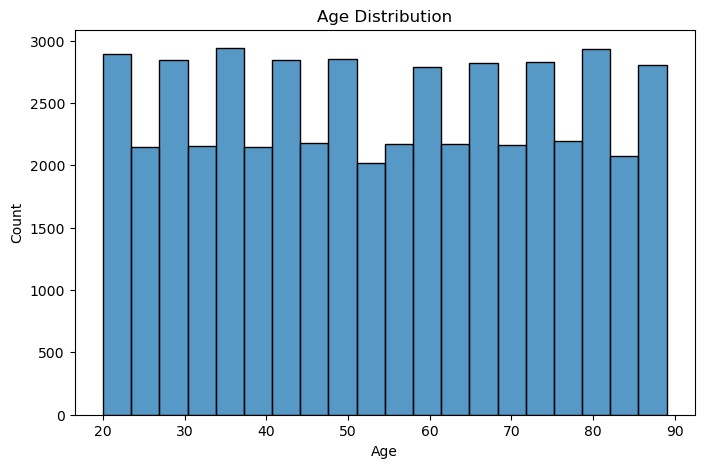

In [26]:
plt.figure(figsize=(8,5))
sns.histplot(data["Age"], bins=20)

plt.title("Age Distribution")
plt.show()

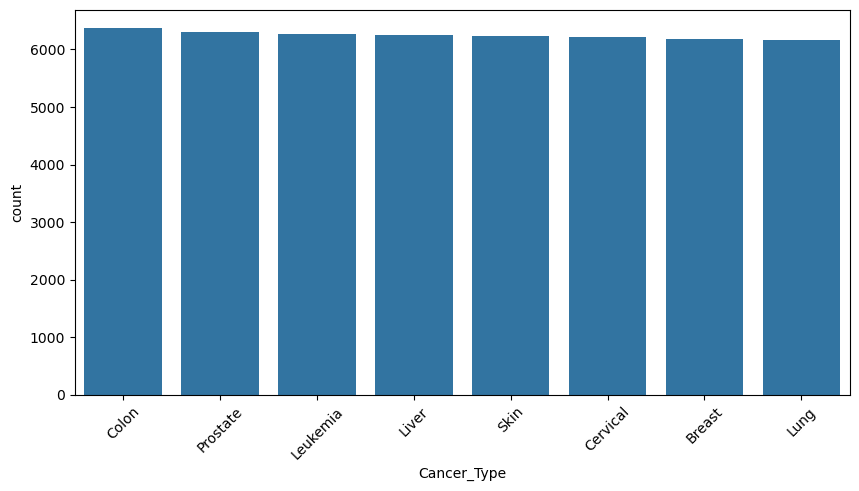

In [27]:
plt.figure(figsize=(10,5))

sns.countplot(
    x="Cancer_Type",
    data=data,
    order=data["Cancer_Type"].value_counts().index
)

plt.xticks(rotation=45)

plt.show()

Country Analysis

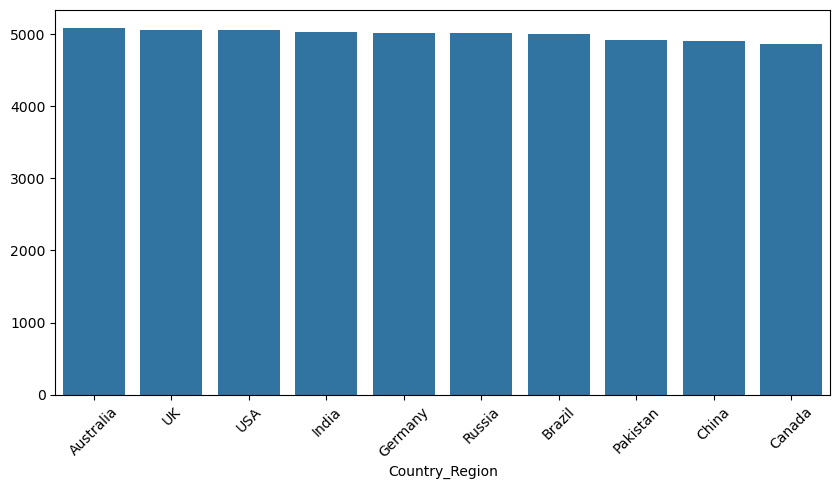

In [28]:
country_cases = data["Country_Region"].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=country_cases.index,
    y=country_cases.values
)

plt.xticks(rotation=45)

plt.show()

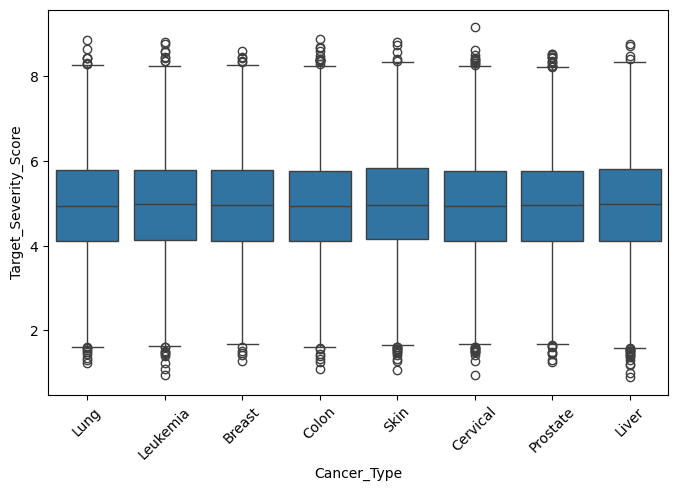

In [29]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Cancer_Type",
    y="Target_Severity_Score",
    data=data
)

plt.xticks(rotation=45)

plt.show()

Survival Analysis

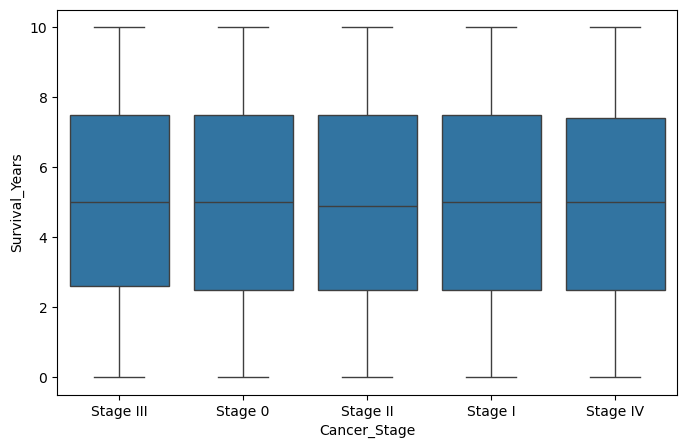

In [30]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Cancer_Stage",
    y="Survival_Years",
    data=data
)

plt.show()

Treatment Cost Analysis

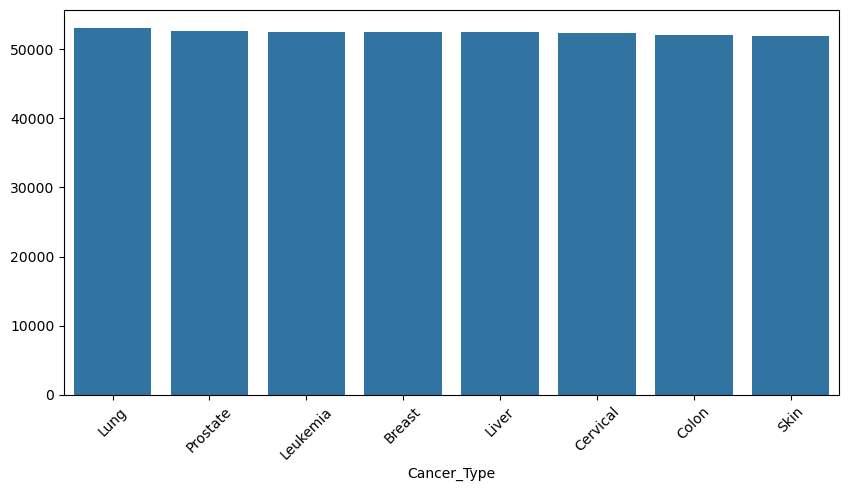

In [31]:
cost_by_type = data.groupby(
    "Cancer_Type"
)["Treatment_Cost_USD"].mean().sort_values(
    ascending=False
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=cost_by_type.index,
    y=cost_by_type.values
)

plt.xticks(rotation=45)

plt.show()

Risk Factor Analysis

Smoking vs Severity

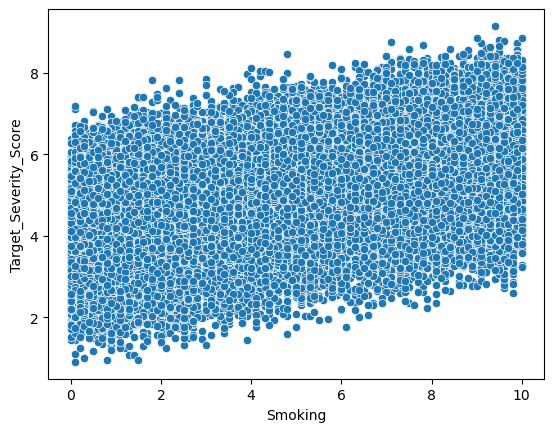

In [34]:
sns.scatterplot(
    x="Smoking",
    y="Target_Severity_Score",
    data=data
)

plt.show()

Obesity vs Severity

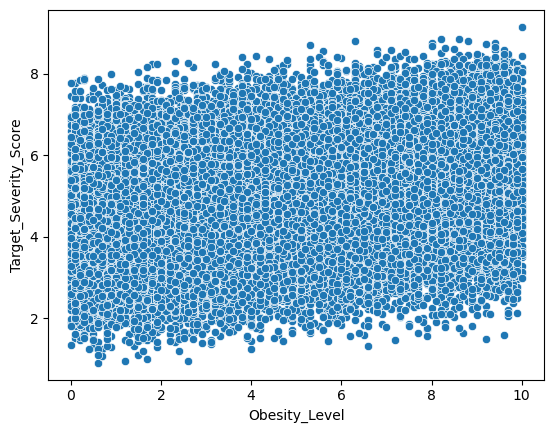

In [35]:
sns.scatterplot(
    x="Obesity_Level",
    y="Target_Severity_Score",
    data=data
)

plt.show()

Predictive Analytics

Linear Regression

In [45]:
X = data[
[
'Age',
'Smoking',
'Alcohol_Use',
'Obesity_Level',
'Air_Pollution',
'Genetic_Risk',
'Treatment_Cost_USD'
]
]

y = data['Target_Severity_Score']

In [48]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)


In [ ]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train,y_train)
y_pred_lr = lr.predict(X_test)

In [49]:
from sklearn.metrics import r2_score,mean_absolute_error
print("R2 Score:",
      r2_score(y_test,y_pred_lr))
print("MAE:",
      mean_absolute_error(y_test,y_pred_lr))

R2 Score: 0.9999941381117425
MAE: 0.0024962663155966786


MODEL2.Random Forest Regressor


In [50]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100,random_state=42)
rf.fit(X_train,y_train)
y_pred_rf = rf.predict(X_test)

In [52]:
print("R2 Score:",
      r2_score(y_test,y_pred_rf))

print("MAE:",
      mean_absolute_error(y_test,y_pred_rf))

R2 Score: 0.9825449698212457
MAE: 0.12462147000000004


In [56]:
comparison = pd.DataFrame({

'Model':['Linear Regression',
          'Random Forest'],

'R2 Score':[
r2_score(y_test,y_pred_lr),
r2_score(y_test,y_pred_rf)
],

'MAE':[
mean_absolute_error(y_test,y_pred_lr),
mean_absolute_error(y_test,y_pred_rf)
]

})

comparison

,Model,R2 Score,MAE
0,Linear Regression,0.999994,0.002496
1,Random Forest,0.982545,0.124621


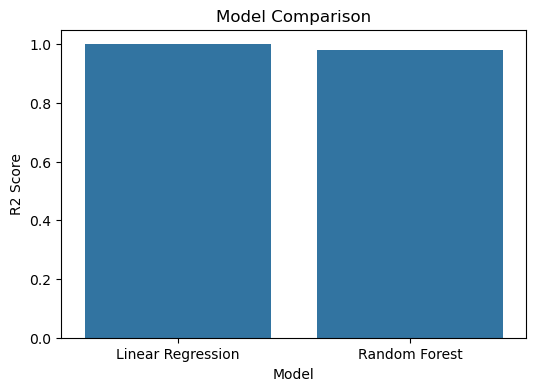

In [57]:
plt.figure(figsize=(6,4))

sns.barplot(x='Model',y='R2 Score',data=comparison)

plt.title("Model Comparison")
plt.show()

In [58]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
1,Smoking,0.234942
5,Genetic_Risk,0.229651
6,Treatment_Cost_USD,0.214305
2,Alcohol_Use,0.130557
4,Air_Pollution,0.128214
3,Obesity_Level,0.058584
0,Age,0.003747


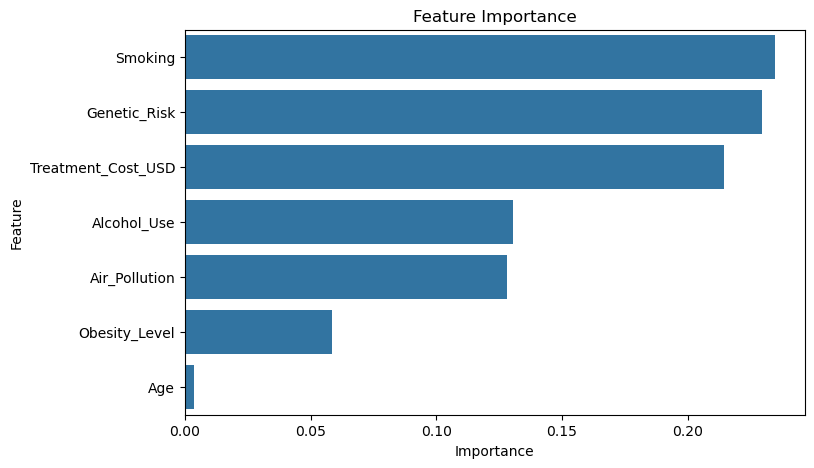

In [59]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance
)

plt.title("Feature Importance")
plt.show()

The model showed that smoking, genetic risk, and air pollution have the biggest impact on cancer severity. This suggests that focusing on these risk factors could help reduce severe cancer case

Correlation Analysis

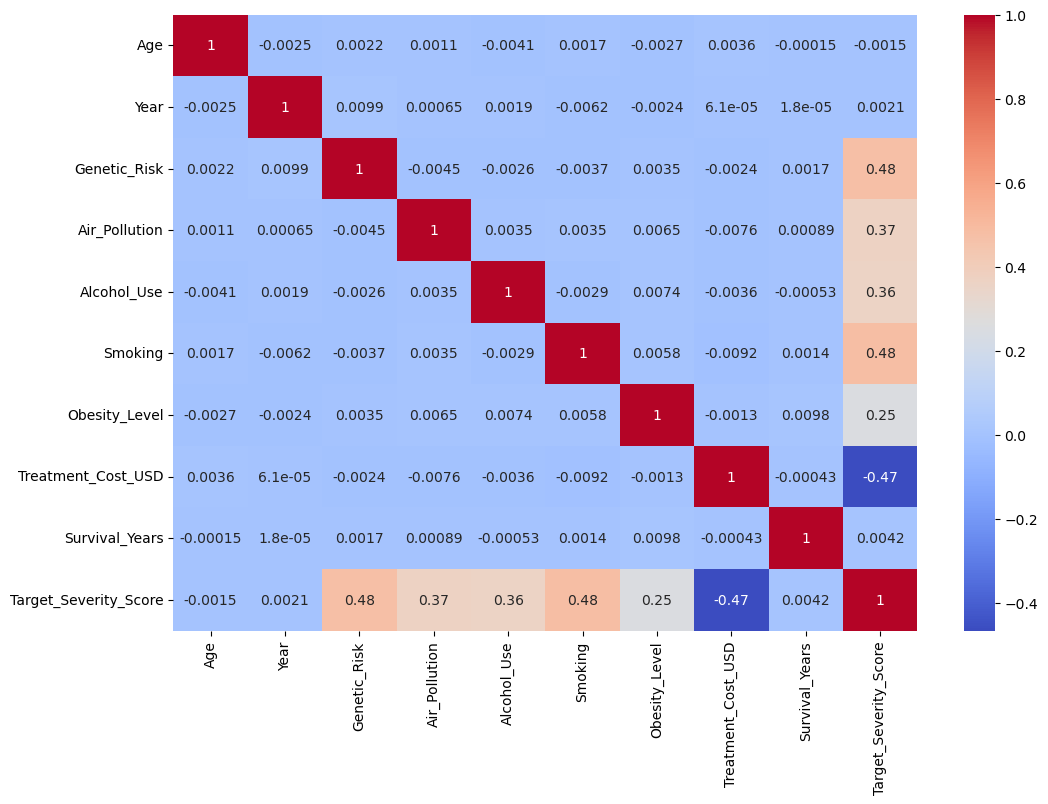

In [36]:
corr = data.select_dtypes(
    include=np.number
).corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.show()

Statistical Validation

In [37]:
male = data[data["Gender"]=="Male"][
    "Target_Severity_Score"
]

female = data[data["Gender"]=="Female"][
    "Target_Severity_Score"
]

stats.ttest_ind(male,female)

TtestResult(statistic=np.float64(-1.2832611969302516), pvalue=np.float64(0.19940945860084588), df=np.float64(33503.0))

In [38]:
data.groupby(
    "Cancer_Type"
)["Target_Severity_Score"].mean().sort_values(
    ascending=False
)

Cancer_Type
Skin        4.969957
Leukemia    4.967952
Liver       4.964380
Cervical    4.951461
Breast      4.947764
Prostate    4.943358
Lung        4.937604
Colon       4.927520
Name: Target_Severity_Score, dtype: float64

In [41]:
data.groupby("Age_Group")["Survival_Years"].mean()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_14424\29471703.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby("Age_Group")["Survival_Years"].mean()


Age_Group
young         4.990792
adult         5.012498
middle age    5.001557
senior        5.009424
Name: Survival_Years, dtype: float64

In [42]:
data.groupby(
    "Country_Region"
)["Treatment_Cost_USD"].mean().sort_values(
    ascending=False
)

Country_Region
China        52899.413814
USA          52878.648158
Germany      52769.251439
Australia    52621.637121
Canada       52584.225541
Brazil       52540.892254
Russia       52319.453980
India        52284.925133
UK           52199.851308
Pakistan     51567.959389
Name: Treatment_Cost_USD, dtype: float64

In [61]:
import pandas as pd
from sqlalchemy import create_engine

# PostgreSQL Connection
username = "postgres"
password = "abhi2005"
host = "localhost"
port = "5432"
database = "cancer_db"

engine = create_engine(
    f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}"
)

# Load DataFrame into PostgreSQL
data.to_sql(
    "cancer_patients",
    engine,
    if_exists="replace",
    index=False
)

print("Data loaded successfully!")

Data loaded successfully!
